# dbitseq

In [1]:
import anndata as ad
import numpy as np
import scanpy as sc
import pandas as pd


import seaborn as sns
from collections import Counter
from sklearn.neighbors import NearestNeighbors
import pandas as pd
import sys
sys.path.append('..')
import matplotlib.pyplot as plt
from sklearn.metrics import adjusted_rand_score

from src.interface import UnitedNet
from src.configs import *
from scipy.stats import spearmanr, pearsonr

/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
def split_data(test_batch):
    adata_rna_train = adata_rna_all[adata_rna_all.obs['batch'] != test_batch]
    adata_morph_train = adata_morph_all[adata_morph_all.obs['batch'] != test_batch]
    adata_mrna_niche_train = adata_mrna_niche_all[adata_mrna_niche_all.obs['batch'] != test_batch]

    adata_rna_test = adata_rna_all[adata_rna_all.obs['batch'] == test_batch]
    adata_morph_test = adata_morph_all[adata_morph_all.obs['batch'] == test_batch]
    adata_mrna_niche_test = adata_mrna_niche_all[adata_mrna_niche_all.obs['batch'] == test_batch]

    return [adata_rna_train, adata_morph_train, adata_mrna_niche_train], [adata_rna_test, adata_morph_test,
                                                                          adata_mrna_niche_test]


In [3]:
from sklearn import preprocessing
def change_label(adata,batch):
    adata.obs['batch'] = batch
    adata.obs['imagecol'] = adata.obs['array_col']
    adata.obs['imagerow'] = adata.obs['array_row']
    adata.obs['label'] = adata.obs['cell_type']
    return adata

In [4]:
def pre_ps(adata_list,sc_pre = None):
    adata_list_all = [ad_x.copy() for ad_x in adata_list]
    scalars = []
    assert (adata_list_all[0].X>=0).all(), "poluted input"
    for idx, mod in enumerate(adata_list_all):
        t_x = mod.X
        if sc_pre != None:
            scaler = sc_pre[idx]
        else:
            scaler = preprocessing.StandardScaler().fit(t_x)
        t_x = scaler.transform(t_x)
        mod.X = t_x
        adata_list_all[idx] = mod
        scalars.append(scaler)

    return adata_list_all,scalars

# load dbitseq data

In [5]:
technique = 'dbitseq'
data_path = f"../data/{technique}"
device = "cpu"

In [6]:
adata_niche_rna_train = sc.read_h5ad(f'{data_path}/adata_niche_rna_train.h5ad')
adata_niche_rna_test = sc.read_h5ad(f'{data_path}/adata_niche_rna_test.h5ad')

adata_rna_train = sc.read_h5ad(f'{data_path}/adata_rna_train.h5ad')
adata_rna_test = sc.read_h5ad(f'{data_path}/adata_rna_test.h5ad')

adata_protein_train = sc.read_h5ad(f'{data_path}/adata_protein_train.h5ad')
adata_protein_test = sc.read_h5ad(f'{data_path}/adata_protein_test.h5ad')


In [7]:
adata_rna_train = change_label(adata_rna_train,'train')
adata_protein_train=change_label(adata_protein_train,'train')
adata_niche_rna_train=change_label(adata_niche_rna_train,'train')

adata_rna_test = change_label(adata_rna_test,'test')
adata_protein_test = change_label(adata_protein_test,'test')
adata_niche_rna_test = change_label(adata_niche_rna_test,'test')

adatas_train = [adata_rna_train, adata_protein_train, adata_niche_rna_train]
adatas_test = [adata_rna_test, adata_protein_test, adata_niche_rna_test]

adatas_all = []
for ad_train, ad_test in zip(adatas_train,adatas_test):
    ad_all = ad_train.concatenate(ad_test,batch_key='sample')
    ad_all = change_label(ad_all,'test')
    adatas_all.append(ad_all)
adatas_all,_ = pre_ps(adatas_all)    
    

adatas_train,_ = pre_ps(adatas_train)   
adatas_test,_ = pre_ps(adatas_test)   


/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/anndata/_core/anndata.py:1785: FutureWarning: X.dtype being converted to np.float32 from float64. In the next version of anndata (0.9) conversion will not be automatic. Pass dtype explicitly to avoid this warning. Pass `AnnData(X, dtype=X.dtype, ...)` to get the future behavour.
  [AnnData(sparse.csr_matrix(a.shape), obs=a.obs) for a in all_adatas],


# Train and finetune UnitedNet

In [8]:
train_model = True
if train_model:
    technique = 'dbitseq'
    data_path = f"../data/{technique}"
    root_save_path = f"../saved_results/dbitseq"
    model = UnitedNet(root_save_path, device=device, technique=dbitseq_config)
    model.train(adatas_train,verbose=True)
    model.finetune(adatas_all,verbose=True)
else:
    technique = 'dbitseq'
    data_path = f"../data/{technique}"
    root_save_path = f"../saved_results/dbitseq"
    model = UnitedNet(root_save_path, device=device, technique=dbitseq_config)



training


  0%|                                                                                            | 0/20 [00:00<?, ?it/s]



Losses                   Value
-------------------  ---------
generator_loss       0.0238486
translation_loss     0.821206
contrastive_loss     0.224674
discriminator_loss   0.0500272
reconstruction_loss  0.708817
best_head            7
best model saved at ../saved_results/dbitseq/train_best.pt 



/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/tabulate/__init__.py:108: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  or (len(row) >= 2 and row[1] == SEPARATING_LINE)
  5%|████▏                                                                               | 1/20 [00:49<15:44, 49.70s/it]



Metrics    Value
---------  -------------------------------------------------------
r2         [[ 0.00088249 -0.00083343  0.00106509]
            [ 0.67511493  0.81739018  0.35952386]
            [ 0.03532821  0.00256502  0.05527568]]
confusion  [[  0   1  14  25  41   0   0   0   0   0   0   0   0]
            [  0  16  12   7  40   7   0   0   0   0   0   1   0]
            [  0  16  23  36  44   4   0   0   0   0   0   1   0]
            [  0   9  20  57  33   1   0   0   0   0   0   1   0]
            [  0   0  31   6 127   1   0   0   0   0   0   0   0]
            [  0   2   6   1  56   7   0   0   0   0   0   0   0]
            [  0   0   7   2   8   0   0   0   0   0   0   0   0]
            [  0   0   0   0   6   0   0   0   0   0   0   0   0]
            [  0   1   1   2   5   0   0   0   0   0   0   0   0]
            [  0   1   6  32   5   0   0   0   0   0   0   0   0]
            [  0   0   2   1  16   0   0   0   0   0   0   0   0]
            [  0   0   0   2   1   0 

...



Metrics    Value
---------  -------------------------------------------------------
r2         [[0.29653227 0.20174107 0.27047577]
            [0.93554208 0.95885654 0.91029589]
            [0.72463989 0.50769844 0.74741666]]
confusion  [[ 53   1   0   0   1   4   1   8   0  10   0  23   0]
            [  0  40   1   0   2  11   8  36   0   1   0   5   0]
            [  0  33  60  10   0   5  23   8   0   0   0  16   0]
            [  2   1  18  89   0   0  28   0   0  11   0   2   0]
            [  7   2   2   0 101  41   1  32   0   0   0  21   0]
            [  0  18   1   0  43  11   1  15   0   0   0   1   0]
            [  9   0   1   0   0   0   8   0   0   2   0   1   0]
            [  0   0   0   0   0   0   0   5   0   0   0   2   0]
            [  0   0   1   1   0   0   1   0   0   8   0   1   0]
            [ 27   0   0   0   0   0   0   0   0  25   0   3   0]
            [  5   0   0  12   0   0   6   0   0   0   0   0   0]
            [  0   3   0   0   0   0   0   0  

/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/tabulate/__init__.py:108: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  or (len(row) >= 2 and row[1] == SEPARATING_LINE)
 90%|███████████████████████████████████████████████████████████████████████████▌        | 9/10 [09:21<01:02, 62.14s/it]



Metrics    Value
---------  ------------------------------------------
r2         [[0.30989329 0.21212398 0.28580603]
            [0.94347638 0.95381827 0.9255527 ]
            [0.73341349 0.53839957 0.75923335]]
confusion  [[50  0  0  0  1  4  4  9  0 10  0 23  0]
            [ 0 39  2  0  3 12  8 34  0  1  0  5  0]
            [ 0 32 59 13  0  5 22  7  0  1  0 16  0]
            [ 2  1 15 92  0  1 27  0  0 11  0  2  0]
            [ 7  2  2  0 98 42  0 35  0  0  0 21  0]
            [ 0 18  0  0 42 11  1 14  0  0  0  4  0]
            [ 9  0  1  0  0  0  8  0  0  2  0  1  0]
            [ 0  0  0  0  0  0  0  5  0  0  0  2  0]
            [ 0  0  1  1  0  0  1  0  0  8  0  1  0]
            [25  0  0  0  0  0  2  0  0 24  0  4  0]
            [ 5  0  0 12  0  0  6  0  0  0  0  0  0]
            [ 0  2  0  0  0  0  0  0  0  1  0  3  0]
            [ 0  0  0  0  0  1  0  1  0  0  0  2  0]]
acc        0.4155982905982906
ari        0.2614797581592037
nmi        0.3996417580145927


/home/ubuntu/anaconda3/envs/UnitedNet/lib/python3.7/site-packages/tabulate/__init__.py:108: FutureWarning: elementwise comparison failed; returning scalar instead, but in the future will perform elementwise comparison
  or (len(row) >= 2 and row[1] == SEPARATING_LINE)
100%|███████████████████████████████████████████████████████████████████████████████████| 10/10 [10:24<00:00, 62.44s/it]



Metrics    Value
---------  ------------------------------------------
r2         [[0.32126199 0.21501609 0.29333505]
            [0.94128844 0.94890915 0.9213705 ]
            [0.74332117 0.52734959 0.76492335]]
confusion  [[51  0  0  0  1  9  2  4  2 10  0 22  0]
            [ 0 39  1  0  3 33  8 14  0  1  0  5  0]
            [ 0 32 63 10  0  7 23  4  0  1  0 15  0]
            [ 2  1 18 89  0  0 28  0  0 11  0  2  0]
            [ 7  1  2  0 95 37  2 41  0  0  0 22  0]
            [ 0 18  0  0 42 16  1 11  0  0  0  2  0]
            [ 7  0  1  0  0  0  9  0  0  3  0  1  0]
            [ 0  0  0  0  0  4  0  1  0  0  0  2  0]
            [ 0  0  1  1  0  0  1  0  0  8  0  1  0]
            [27  0  0  0  0  0  0  0  1 24  0  3  0]
            [ 5  0  0 14  0  0  4  0  0  0  0  0  0]
            [ 0  1  0  0  0  0  0  0  0  2  0  3  0]
            [ 0  0  0  0  0  2  0  1  0  0  0  1  0]]
acc        0.4166666666666667
ari        0.261388772087057
nmi        0.40808681211788667


# Predict on all data

In [15]:
import torch
import torchvision

model = UnitedNet(root_save_path, device=device, technique=dbitseq_config)
model.load_model(f"{root_save_path}/train_best.pt",device=torch.device(device))
model.model.device_in_use = device
predict_label = model.predict_label(adatas_all)

print(root_save_path,'ari:',adjusted_rand_score(adatas_all[0].obs['cell_type'],
                    predict_label))

../saved_results/dbitseq ari: 0.25152578771661205


In [16]:
from src.data import create_dataloader
dataloader_test = create_dataloader(
    model.model,
    adatas_train,
    shuffle=False,
    batch_size=model.model.config["train_batch_size"],
)

In [17]:
#smooth and plot results

coord=np.array((list(adatas_all[0].obs['array_row'].astype('int')),
                list(adatas_all[0].obs['array_col'].astype('int')))).T


united_clus=list(predict_label)

coord=np.array((list(adatas_all[0].obs['array_row'].astype('int')),
                list(adatas_all[0].obs['array_col'].astype('int')))).T

nbrs = NearestNeighbors(n_neighbors=5, algorithm='ball_tree').fit(coord)
distances,indices = nbrs.kneighbors(coord)

united_clus_new=[]
for indi,i in enumerate(united_clus):
  np.array(united_clus)[(indices[indi])]
  occurence_count=Counter(np.array(united_clus)[(indices[indi])])
  united_clus_new.append(occurence_count.most_common(1)[0][0])
    

cluster_pl = sns.color_palette('tab20',20)
color_list = [cluster_pl[5],
 cluster_pl[1],
 cluster_pl[2],
 cluster_pl[4],
 cluster_pl[11],
 cluster_pl[6],
 cluster_pl[3],
 cluster_pl[7],
 cluster_pl[8],
 cluster_pl[0]]    

(0.8500000000000001, 48.15, 8.15, 48.85)

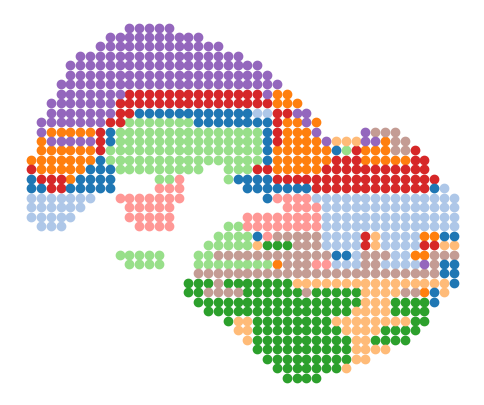

In [18]:
plt.figure(figsize=(6,5))
for idx,clus_id in enumerate(set(united_clus_new)):
    
    plt.scatter(adatas_all[0].obs['array_row'][(united_clus_new==clus_id)],
               adatas_all[0].obs['array_col'][(united_clus_new==clus_id)],
               color=color_list[idx],cmap='tab20')
plt.axis('off')
